**Group 26**

#Part I
## 3.1 Batch mode training using least squares - supervised learning of network weights

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
x_train = np.arange(0, 2*np.pi, 0.1)

x_test = np.arange(0.05, 2 * np.pi, 0.1)

def sin2x(x):
    return np.sin(2 * x)

def square2x(x):
    return np.where(np.sin(2 * x) >= 0, 1, -1)

y_sin_train = sin2x(x_train)
y_sin_test = sin2x(x_test)

y_square_train = square2x(x_train)
y_square_test = square2x(x_test)

In [ ]:
def gaussian_rbf(x, mu, sigma):
    return np.exp(-((x - mu)**2) / (2 * sigma**2))


def RBF_train(x_train,y_train, nodes_mu, variance=0.05):
  n_nodes=len(nodes_mu)
  phi = np.zeros((len(x_train),n_nodes))

  for i in range(n_nodes):
    phi[:,i]=gaussian_rbf(x_train,nodes_mu[i],variance)

  phi_transpose = phi.T

  w = np.linalg.pinv(phi) @ y_train
  return w


def predict(x_test,w, nodes_mu, variance=0.05):
  n_nodes=len(nodes_mu)
  phi_test = np.zeros((len(x_test),n_nodes))

  for i in range(n_nodes):
    phi_test[:,i]=gaussian_rbf(x_test,nodes_mu[i],variance)

  return phi_test @ w


In [ ]:
def residual_error(test,true):
  return np.mean(np.abs(test-true))

In [ ]:
sigma=0.2
max_nodes = 100
for n in range(0,max_nodes):
  nodes_mu= np.linspace(0, 2*np.pi , n)
  w_sin = RBF_train(x_train,y_sin_train,nodes_mu,sigma)
  y_pred_sin = predict(x_test,w_sin,nodes_mu,sigma)
  error_sin = residual_error(y_sin_test,y_pred_sin)
  print("Errors with ", n, " nodes")
  print("Sin:   ", error_sin)

for n in range(0,max_nodes):
  nodes_mu= np.linspace(0, 2*np.pi , n)
  w_square = RBF_train(x_train,y_square_train,nodes_mu,sigma)
  y_pred_square = predict(x_test,w_square,nodes_mu,sigma)
  error_square = residual_error(y_square_test,y_pred_square)

  print("Errors with ", n, " nodes")
  print("Square:", error_square)

for n in range(0,max_nodes):
  nodes_mu= np.linspace(0, 2*np.pi , n)
  w_square = RBF_train(x_train,y_square_train,nodes_mu,sigma)
  y_pred_square = predict(x_test,w_square,nodes_mu,sigma)
  y_corrected = np.where(y_pred_square >= 0, 1, -1)
  error_square = residual_error(y_square_test,y_corrected)

  print("Errors with ", n, " nodes")
  print("Square corrected:", error_square)

Errors with  0  nodes
Sin:    0.6350654065194397
Errors with  1  nodes
Sin:    0.6289522908861167
Errors with  2  nodes
Sin:    0.6259950152335096
Errors with  3  nodes
Sin:    0.6259950152335098
Errors with  4  nodes
Sin:    0.48894114533155975
Errors with  5  nodes
Sin:    0.6259950162648188
Errors with  6  nodes
Sin:    0.4141700806692818
Errors with  7  nodes
Sin:    0.35051006389826794
Errors with  8  nodes
Sin:    0.32079964842680836
Errors with  9  nodes
Sin:    0.2891564405092037
Errors with  10  nodes
Sin:    0.22287486068022916
Errors with  11  nodes
Sin:    0.1727804613194528
Errors with  12  nodes
Sin:    0.12648507483142724
Errors with  13  nodes
Sin:    0.08879421478200324
Errors with  14  nodes
Sin:    0.059001151961144326
Errors with  15  nodes
Sin:    0.038093265102944765
Errors with  16  nodes
Sin:    0.02343519731534985
Errors with  17  nodes
Sin:    0.014194460509107568
Errors with  18  nodes
Sin:    0.008382539726025082
Errors with  19  nodes
Sin:    0.005268156857

## 3.2 Regression with noise

In [ ]:
y_sin_train_noisy = y_sin_train + np.random.normal(0, np.sqrt(0.1), len(y_sin_train))
y_sin_test_noisy = y_sin_test + np.random.normal(0, np.sqrt(0.1), len(y_sin_test))

y_square_train_noisy = y_square_train + np.random.normal(0, np.sqrt(0.1), len(y_square_train))
y_square_test_noisy = y_square_test + np.random.normal(0, np.sqrt(0.1), len(y_square_test))

In [ ]:
def delta_rule(x_train,y_train, nodes_mu, sigma, eta=0.1, epochs=50):
  w = np.random.uniform(0,1,len(nodes_mu))
  indices = np.arange(len(x_train))

  for e in range(epochs):
    np.random.shuffle(indices)
    for i in indices:
      phi = gaussian_rbf(x_train[i],nodes_mu,sigma)
      phi_transpose = phi.T
      y_pred = phi @ w
      error = y_train[i] - y_pred
      w = w + eta * error * phi

  return w

In [ ]:
def rmse_error(test, true):
    mse = np.mean((test - true)**2)
    rmse = np.sqrt(mse)
    return rmse

Final Error with sigma =  0.5
RBF:  7.640837205302668
Delta:  0.35863010284940855
Final Error with sigma =  0.25
RBF:  15.525019629653746
Delta:  0.4250141612746188
Final Error with sigma =  0.1
RBF:  0.5164846481597184
Delta:  0.42241775148675664
Final Error with sigma =  0.05
RBF:  1.4605925579457324
Delta:  0.4693090042307767
Final Error with sigma =  0.01
RBF:  44679.13422022747
Delta:  0.7599377945252617


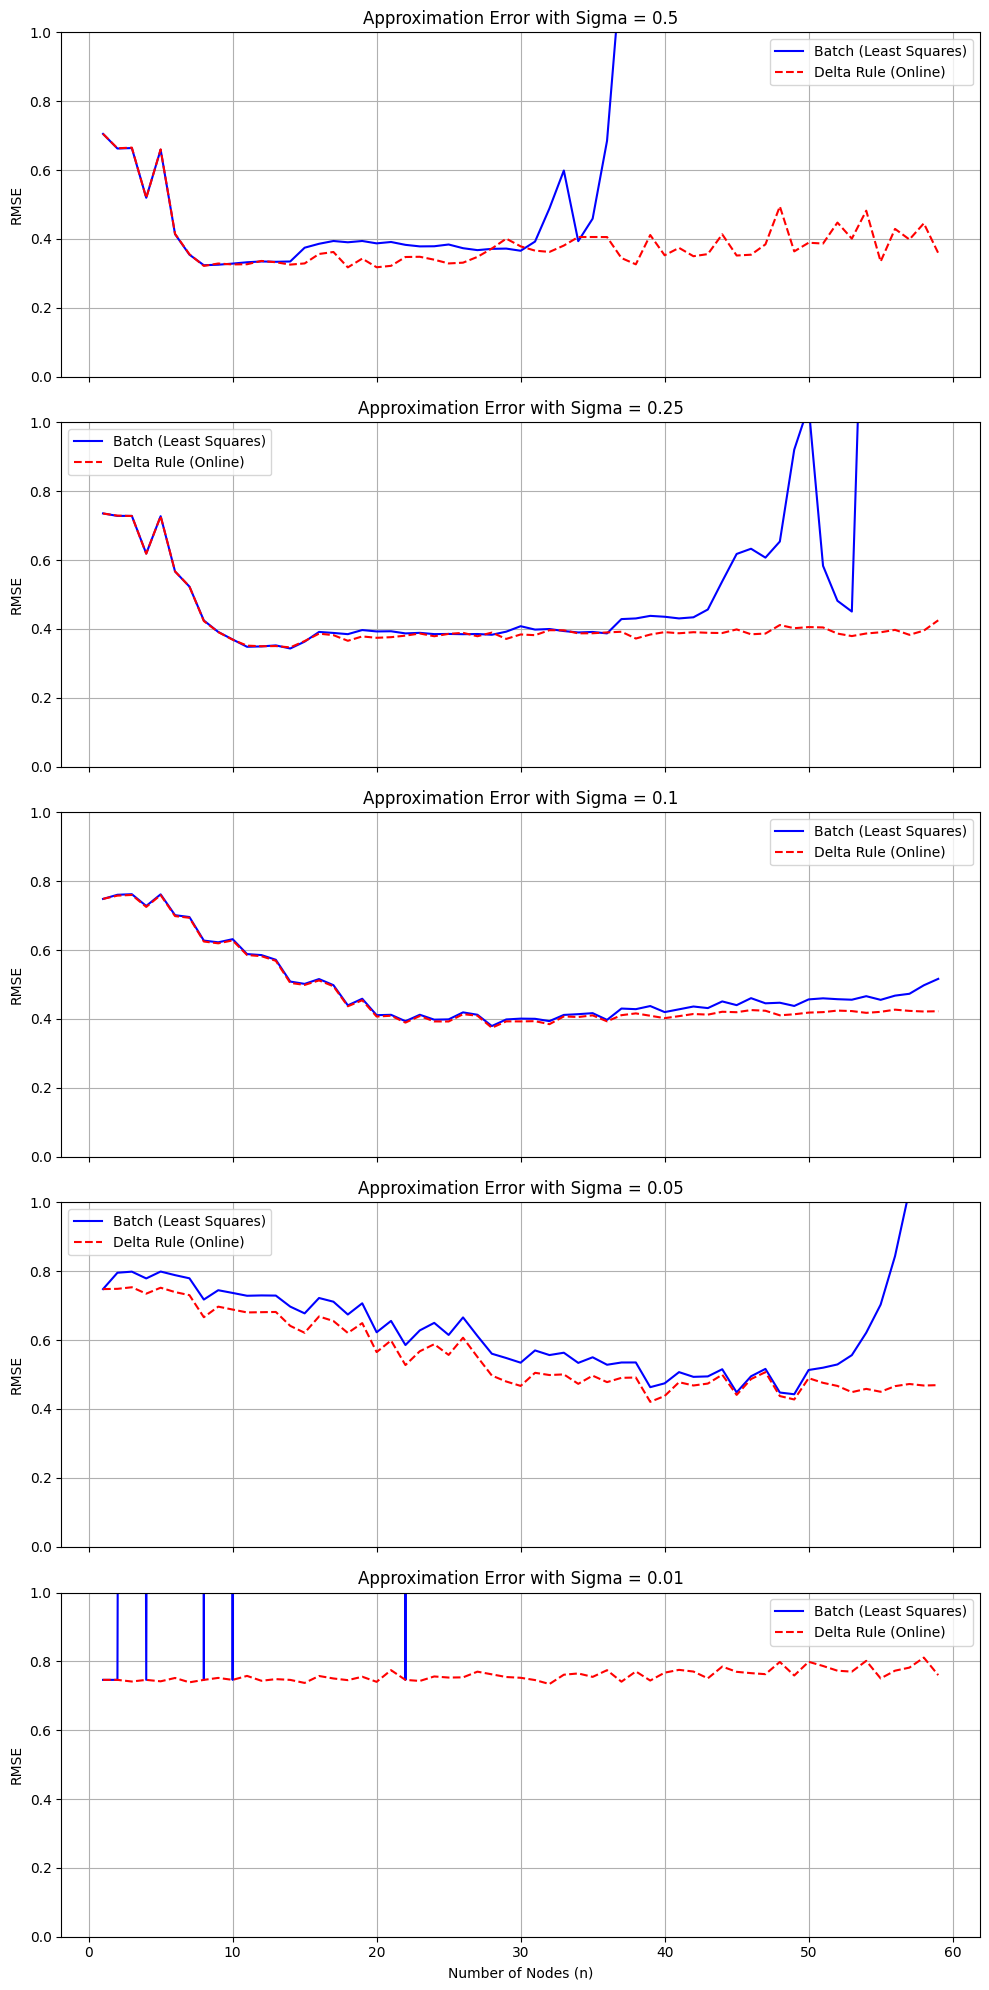

In [ ]:
sigmas = [0.5, 0.25, 0.1, 0.05, 0.01]
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10, 20), sharex=True)

for idx, s in enumerate(sigmas):
    errors_rbf = []
    errors_delta = []

    for n in n_range:
        nodes_mu = np.linspace(0, 2*np.pi, n)

        # Batch Mode (RBF)
        w_rbf = RBF_train(x_train, y_sin_train_noisy, nodes_mu, s)
        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, s)
        errors_rbf.append(rmse_error(y_sin_test_noisy, y_pred_rbf))

        # Delta Rule (Online)
        w_delta = delta_rule(x_train, y_sin_train_noisy, nodes_mu, s)
        y_pred_delta = predict(x_test, w_delta, nodes_mu, s)
        errors_delta.append(rmse_error(y_sin_test_noisy, y_pred_delta))


    print('Final Error with sigma = ', s)
    print('RBF: ', errors_rbf[-1])
    print('Delta: ', errors_delta[-1])
    axes[idx].plot(n_range, errors_rbf, label='Batch (Least Squares)', color='blue')
    axes[idx].plot(n_range, errors_delta, label='Delta Rule (Online)', color='red', linestyle='--')
    axes[idx].set_title(f"Approximation Error with Sigma = {s}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.0)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

Final Error with sigma =  0.5
RBF:  2.261724100563686
Delta:  0.6617021321039502
Final Error with sigma =  0.25
RBF:  1.9397860943475043
Delta:  0.4477272203969093
Final Error with sigma =  0.1
RBF:  0.6561598401980534
Delta:  0.4930866860353488
Final Error with sigma =  0.05
RBF:  2.4319009863447474
Delta:  0.5224393955590939
Final Error with sigma =  0.01
RBF:  88696.4209979857
Delta:  1.0878247624126043


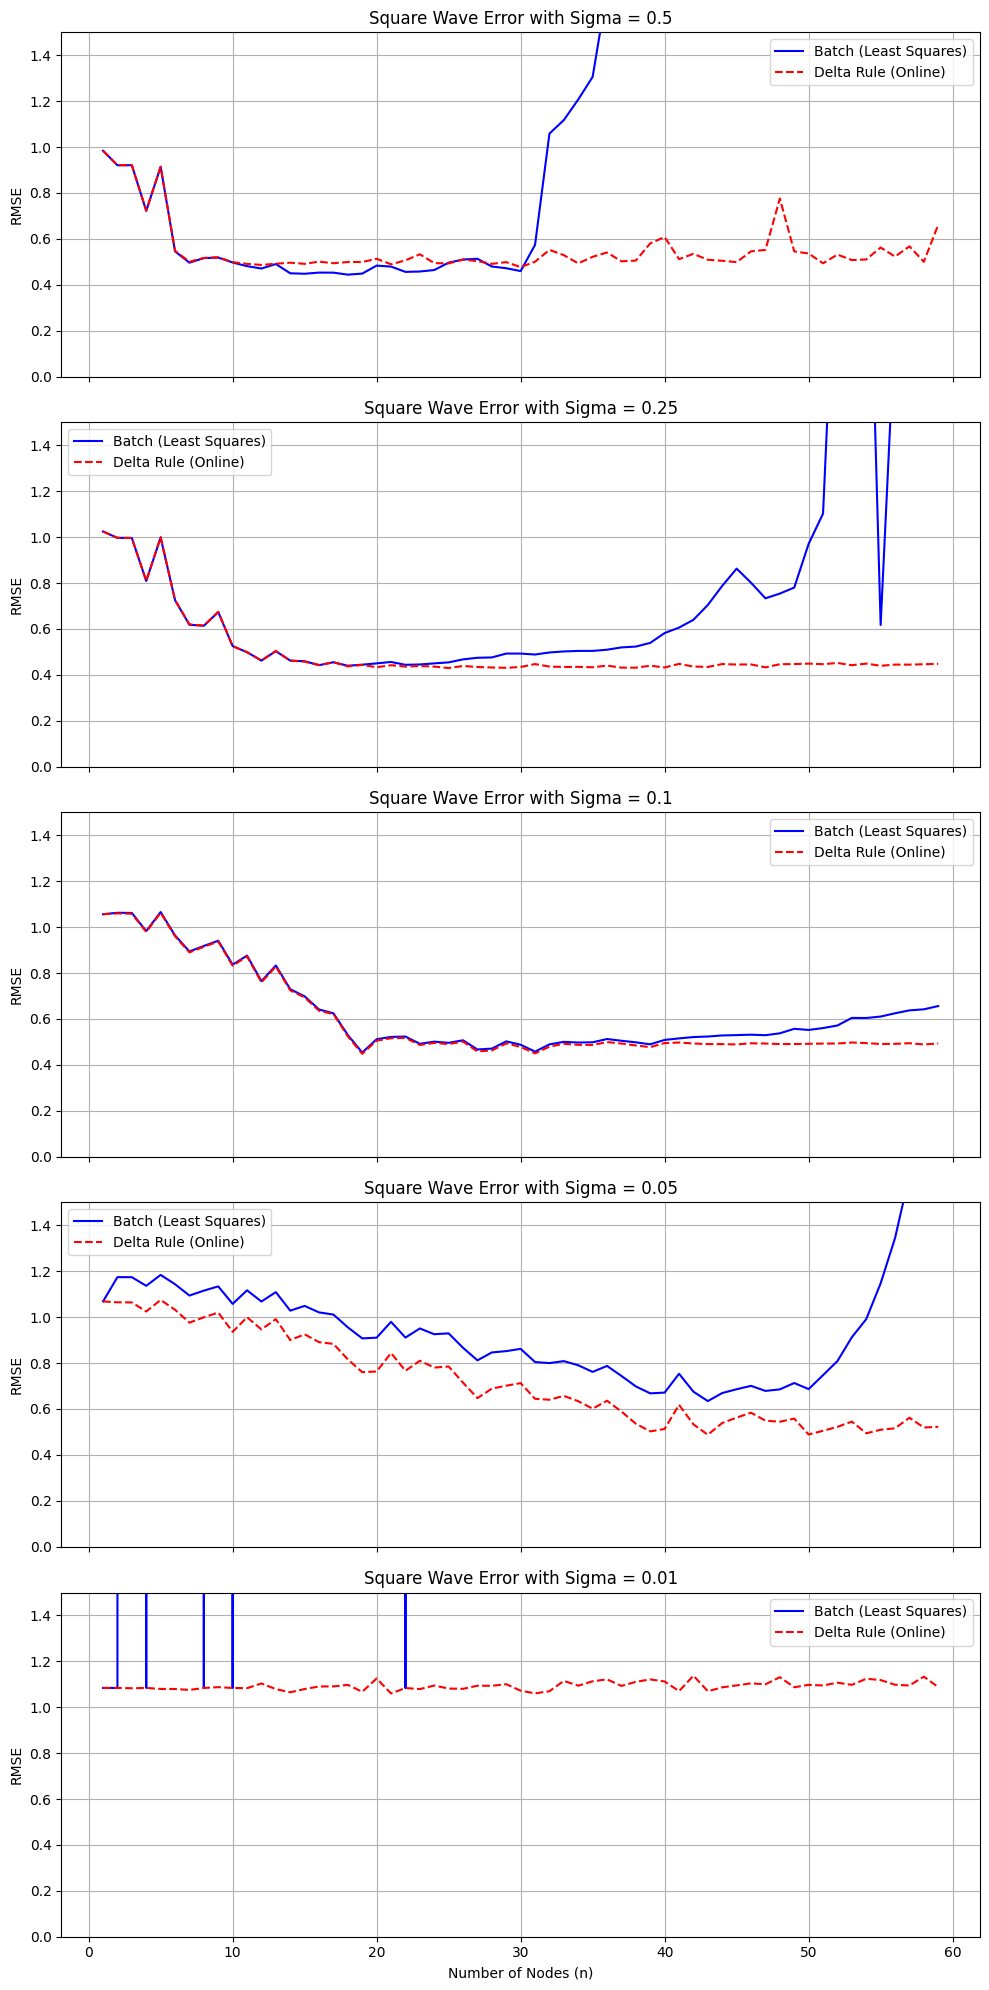

In [ ]:
sigmas = [0.5, 0.25, 0.1, 0.05, 0.01]
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10, 20), sharex=True)

for idx, s in enumerate(sigmas):
    errors_rbf = []
    errors_delta = []

    for n in n_range:
        nodes_mu = np.linspace(0, 2*np.pi, n)

        w_rbf = RBF_train(x_train, y_square_train_noisy, nodes_mu, s)
        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, s)
        errors_rbf.append(rmse_error(y_square_test_noisy, y_pred_rbf))

        w_delta = delta_rule(x_train, y_square_train_noisy, nodes_mu, s)
        y_pred_delta = predict(x_test, w_delta, nodes_mu, s)
        errors_delta.append(rmse_error(y_square_test_noisy, y_pred_delta))


    print('Final Error with sigma = ', s)
    print('RBF: ', errors_rbf[-1])
    print('Delta: ', errors_delta[-1])
    axes[idx].plot(n_range, errors_rbf, label='Batch (Least Squares)', color='blue')
    axes[idx].plot(n_range, errors_delta, label='Delta Rule (Online)', color='red', linestyle='--')
    axes[idx].set_title(f"Square Wave Error with Sigma = {s}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.5)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

Learning rate

Final Error with learning rate =  0.5
square:  0.5059048527455032
sin:  0.46666296379035394
Final Error with learning rate =  0.2
square:  0.49409331892819963
sin:  0.43000089822929854
Final Error with learning rate =  0.1
square:  0.4977578268225895
sin:  0.4261335203693391
Final Error with learning rate =  0.05
square:  0.4854050613006295
sin:  0.41066415091488834
Final Error with learning rate =  0.01
square:  0.44639533264582004
sin:  0.3644061924325445


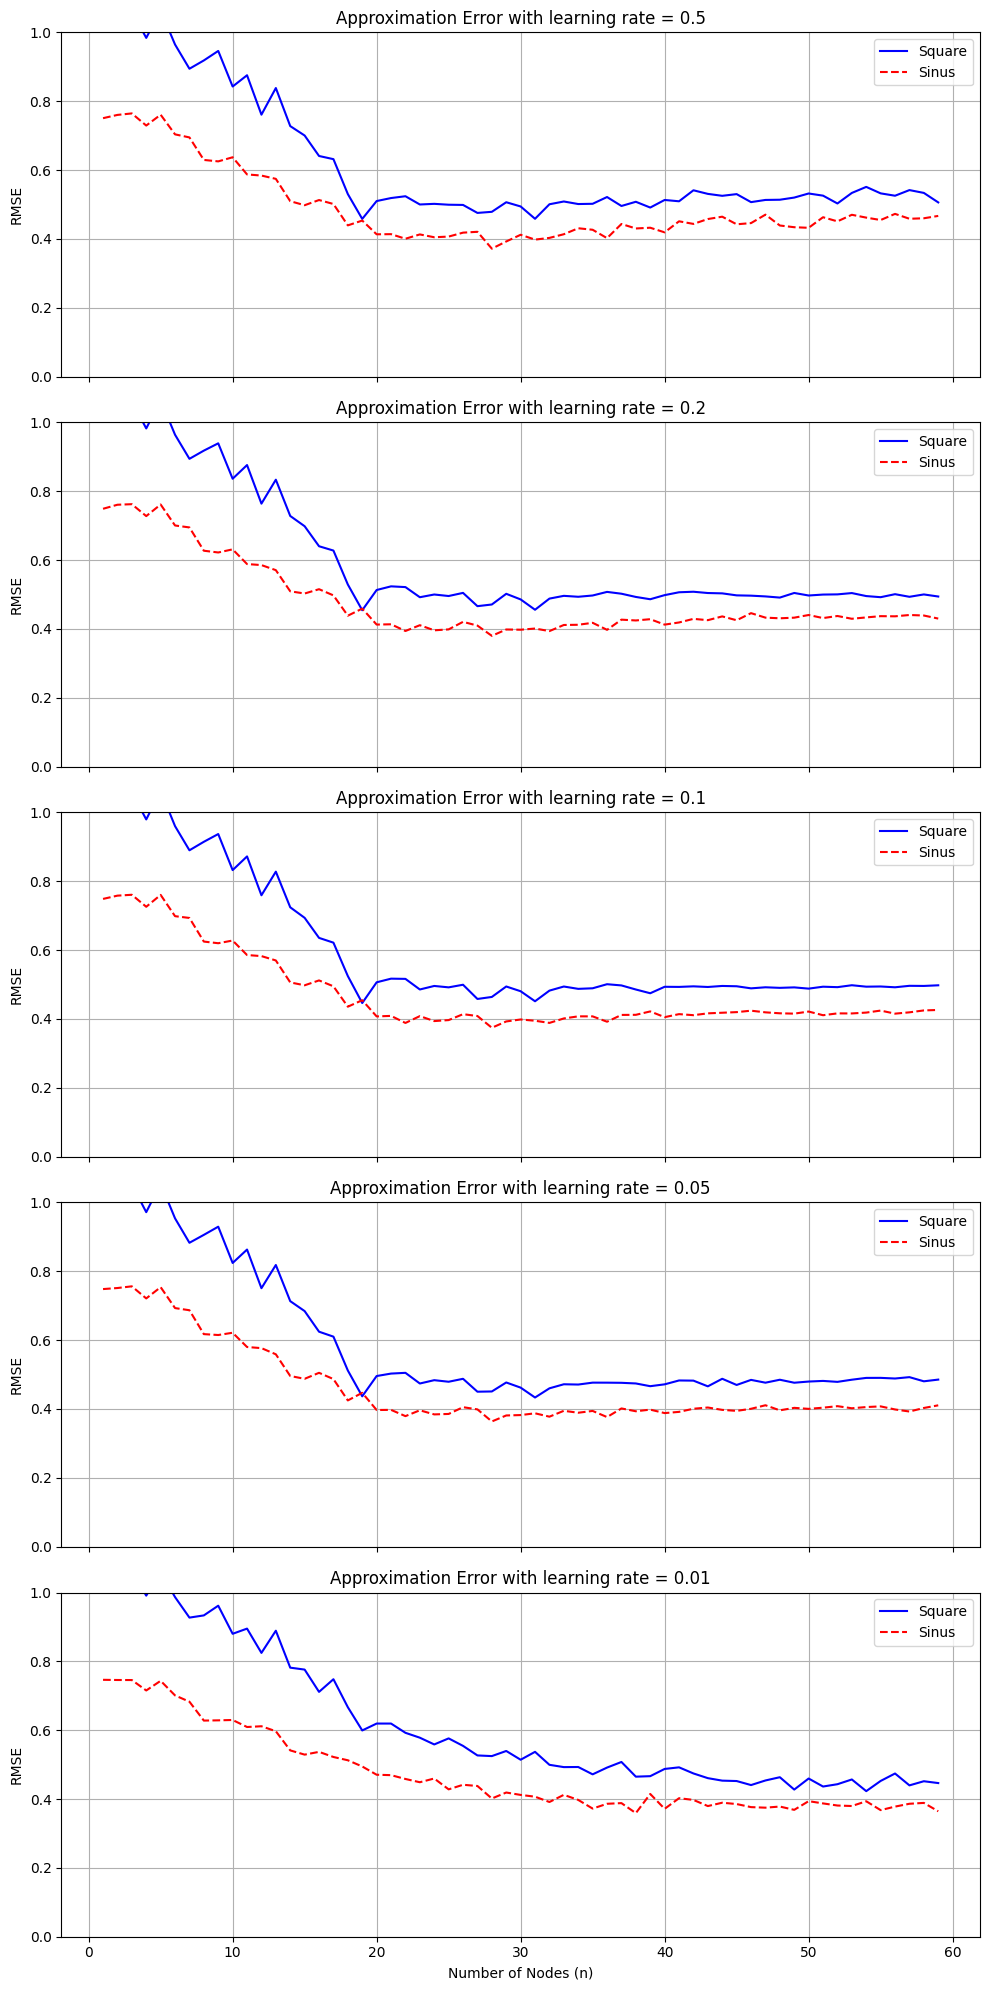

In [ ]:
lr = [0.5, 0.2, 0.1, 0.05, 0.01]
sigma=0.1
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(lr), 1, figsize=(10, 20), sharex=True)

for idx, l in enumerate(lr):
    errors_delta_square = []
    errors_delta_sin = []

    for n in n_range:
        nodes_mu = np.linspace(0, 2*np.pi, n)

        # Batch Mode (RBF)
        w_delta_square = delta_rule(x_train, y_square_train_noisy, nodes_mu, sigma, eta=l)
        y_pred_delta_square = predict(x_test, w_delta_square, nodes_mu, sigma)
        errors_delta_square.append(rmse_error(y_square_test_noisy, y_pred_delta_square))

        # Delta Rule (Online)
        w_delta_sin = delta_rule(x_train, y_sin_train_noisy, nodes_mu, sigma, eta=l)
        y_pred_delta_sin = predict(x_test, w_delta_sin, nodes_mu, sigma)
        errors_delta_sin.append(rmse_error(y_sin_test_noisy, y_pred_delta_sin))


    print('Final Error with learning rate = ', l)
    print('square: ', errors_delta_square[-1])
    print('sin: ', errors_delta_sin[-1])
    axes[idx].plot(n_range, errors_delta_square, label='Square', color='blue')
    axes[idx].plot(n_range, errors_delta_sin, label='Sinus', color='red', linestyle='--')
    axes[idx].set_title(f"Approximation Error with learning rate = {l}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.0)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

With random nodes

Final Error with sigma =  0.5
RBF:  0.24896688797415645
Delta:  0.2382267061063951
Final Error with sigma =  0.25
RBF:  19.78883678839606
Delta:  0.21470733851073212
Final Error with sigma =  0.1
RBF:  69485.89837977226
Delta:  0.26463722669180567
Final Error with sigma =  0.05
RBF:  51885670673.76158
Delta:  0.47749018537773236
Final Error with sigma =  0.01
RBF:  163236327.79804942
Delta:  0.7275139664250571


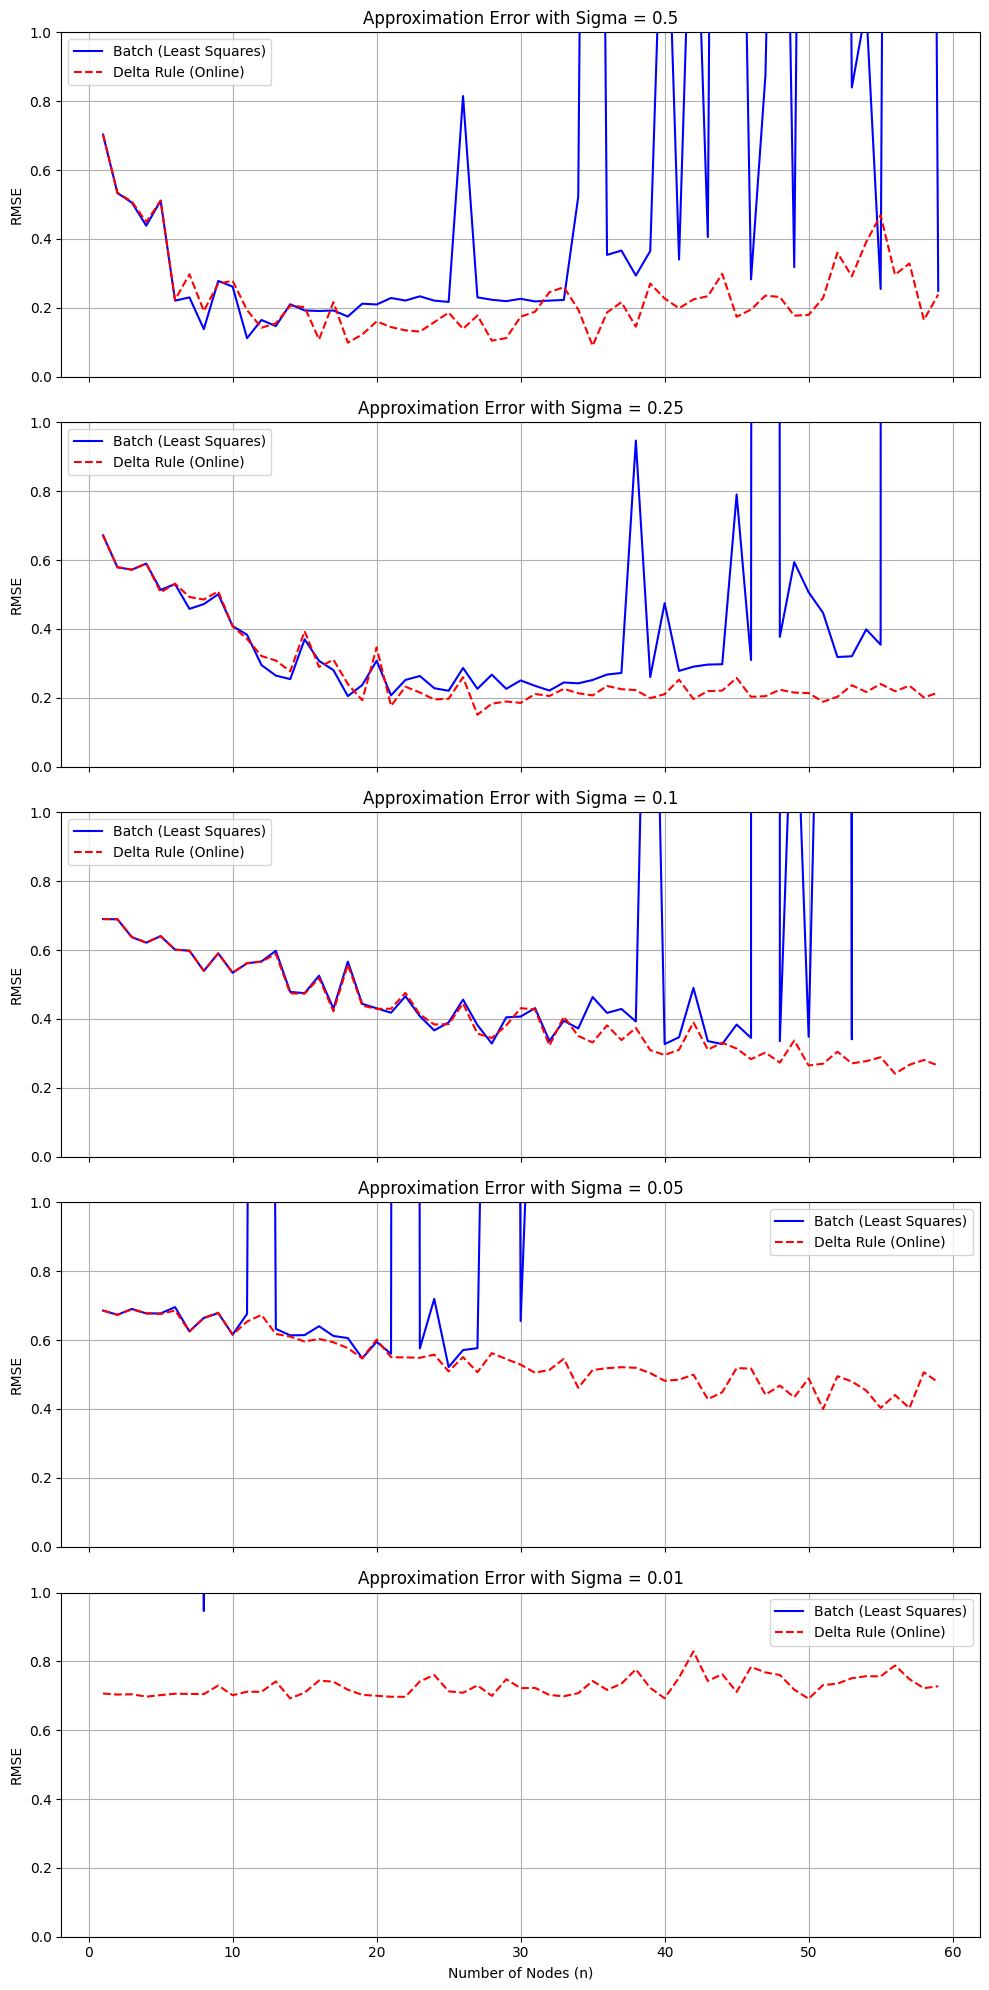

In [ ]:
sigmas = [0.5, 0.25, 0.1, 0.05, 0.01]
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10, 20), sharex=True)

for idx, s in enumerate(sigmas):
    errors_rbf = []
    errors_delta = []

    for n in n_range:
        nodes_mu = np.random.uniform(0, 2 * np.pi, n)

        # Batch Mode (RBF)
        w_rbf = RBF_train(x_train, y_sin_train_noisy, nodes_mu, s)
        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, s)
        errors_rbf.append(rmse_error(y_sin_test, y_pred_rbf))

        # Delta Rule (Online)
        w_delta = delta_rule(x_train, y_sin_train_noisy, nodes_mu, s)
        y_pred_delta = predict(x_test, w_delta, nodes_mu, s)
        errors_delta.append(rmse_error(y_sin_test, y_pred_delta))

    print('Final Error with sigma = ', s)
    print('RBF: ', errors_rbf[-1])
    print('Delta: ', errors_delta[-1])
    axes[idx].plot(n_range, errors_rbf, label='Batch (Least Squares)', color='blue')
    axes[idx].plot(n_range, errors_delta, label='Delta Rule (Online)', color='red', linestyle='--')
    axes[idx].set_title(f"Approximation Error with Sigma = {s}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.0)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

Final Error with sigma =  0.5
RBF:  0.3921426957499029
Delta:  0.49325665000738417
Final Error with sigma =  0.25
RBF:  2.742890752661741
Delta:  0.2671532793105911
Final Error with sigma =  0.1
RBF:  3399996602.932703
Delta:  0.3194412992490573
Final Error with sigma =  0.05
RBF:  1557073780.0028718
Delta:  0.5502105293047536
Final Error with sigma =  0.01
RBF:  165788677177.20566
Delta:  1.0236060911025637


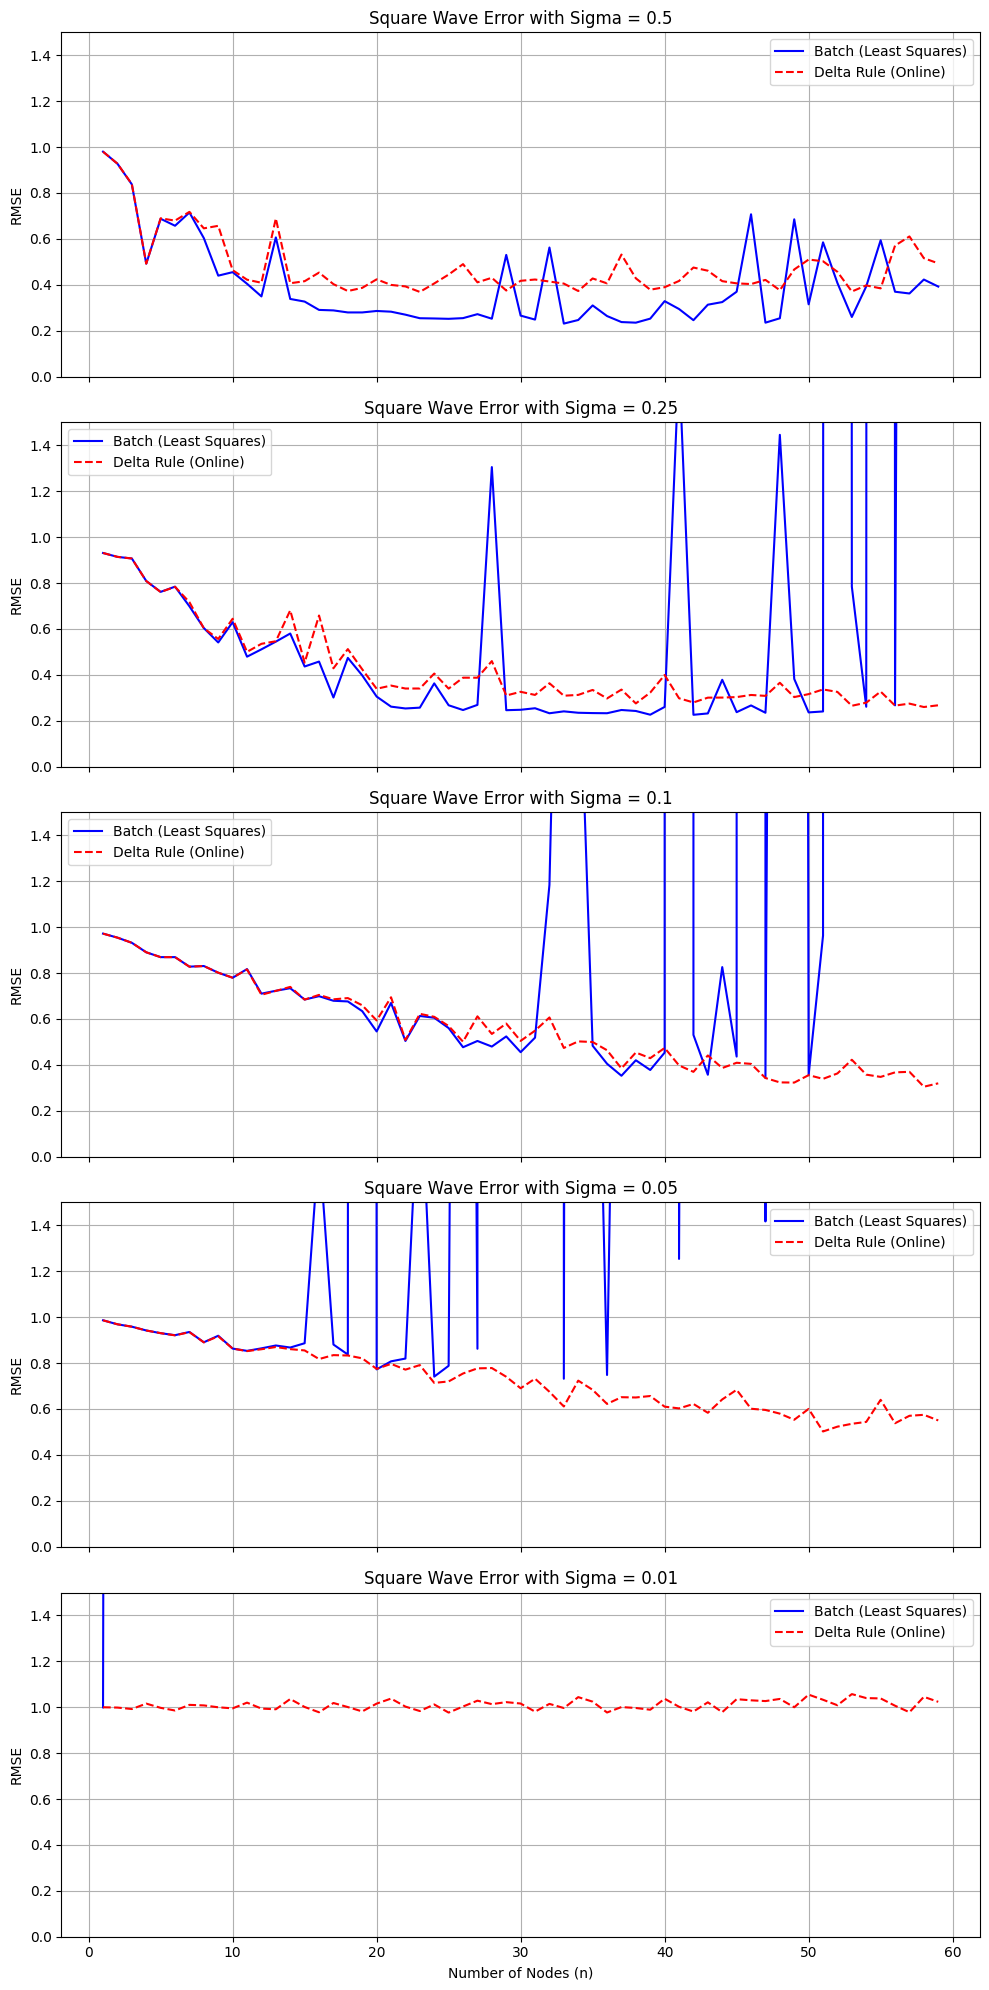

In [ ]:
sigmas = [0.5, 0.25, 0.1, 0.05, 0.01]
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10, 20), sharex=True)

for idx, s in enumerate(sigmas):
    errors_rbf = []
    errors_delta = []

    for n in n_range:
        nodes_mu = np.random.uniform(0, 2 * np.pi, n)

        w_rbf = RBF_train(x_train, y_square_train, nodes_mu, s)
        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, s)
        errors_rbf.append(rmse_error(y_square_test, y_pred_rbf))

        w_delta = delta_rule(x_train, y_square_train, nodes_mu, s)
        y_pred_delta = predict(x_test, w_delta, nodes_mu, s)
        errors_delta.append(rmse_error(y_square_test, y_pred_delta))

    print('Final Error with sigma = ', s)
    print('RBF: ', errors_rbf[-1])
    print('Delta: ', errors_delta[-1])
    axes[idx].plot(n_range, errors_rbf, label='Batch (Least Squares)', color='blue')
    axes[idx].plot(n_range, errors_delta, label='Delta Rule (Online)', color='red', linestyle='--')
    axes[idx].set_title(f"Square Wave Error with Sigma = {s}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.5)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

Clean data

Final Error with sigma =  0.5
RBF:  0.0010191173275185294
Delta:  0.029448599183225545
Final Error with sigma =  0.25
RBF:  0.00011174531398365336
Delta:  0.013590964758644372
Final Error with sigma =  0.1
RBF:  0.002528887260694825
Delta:  0.0314542155996207
Final Error with sigma =  0.05
RBF:  0.032316551853396734
Delta:  0.05373513458844669
Final Error with sigma =  0.01
RBF:  49045.047253077275
Delta:  0.7272557390685019


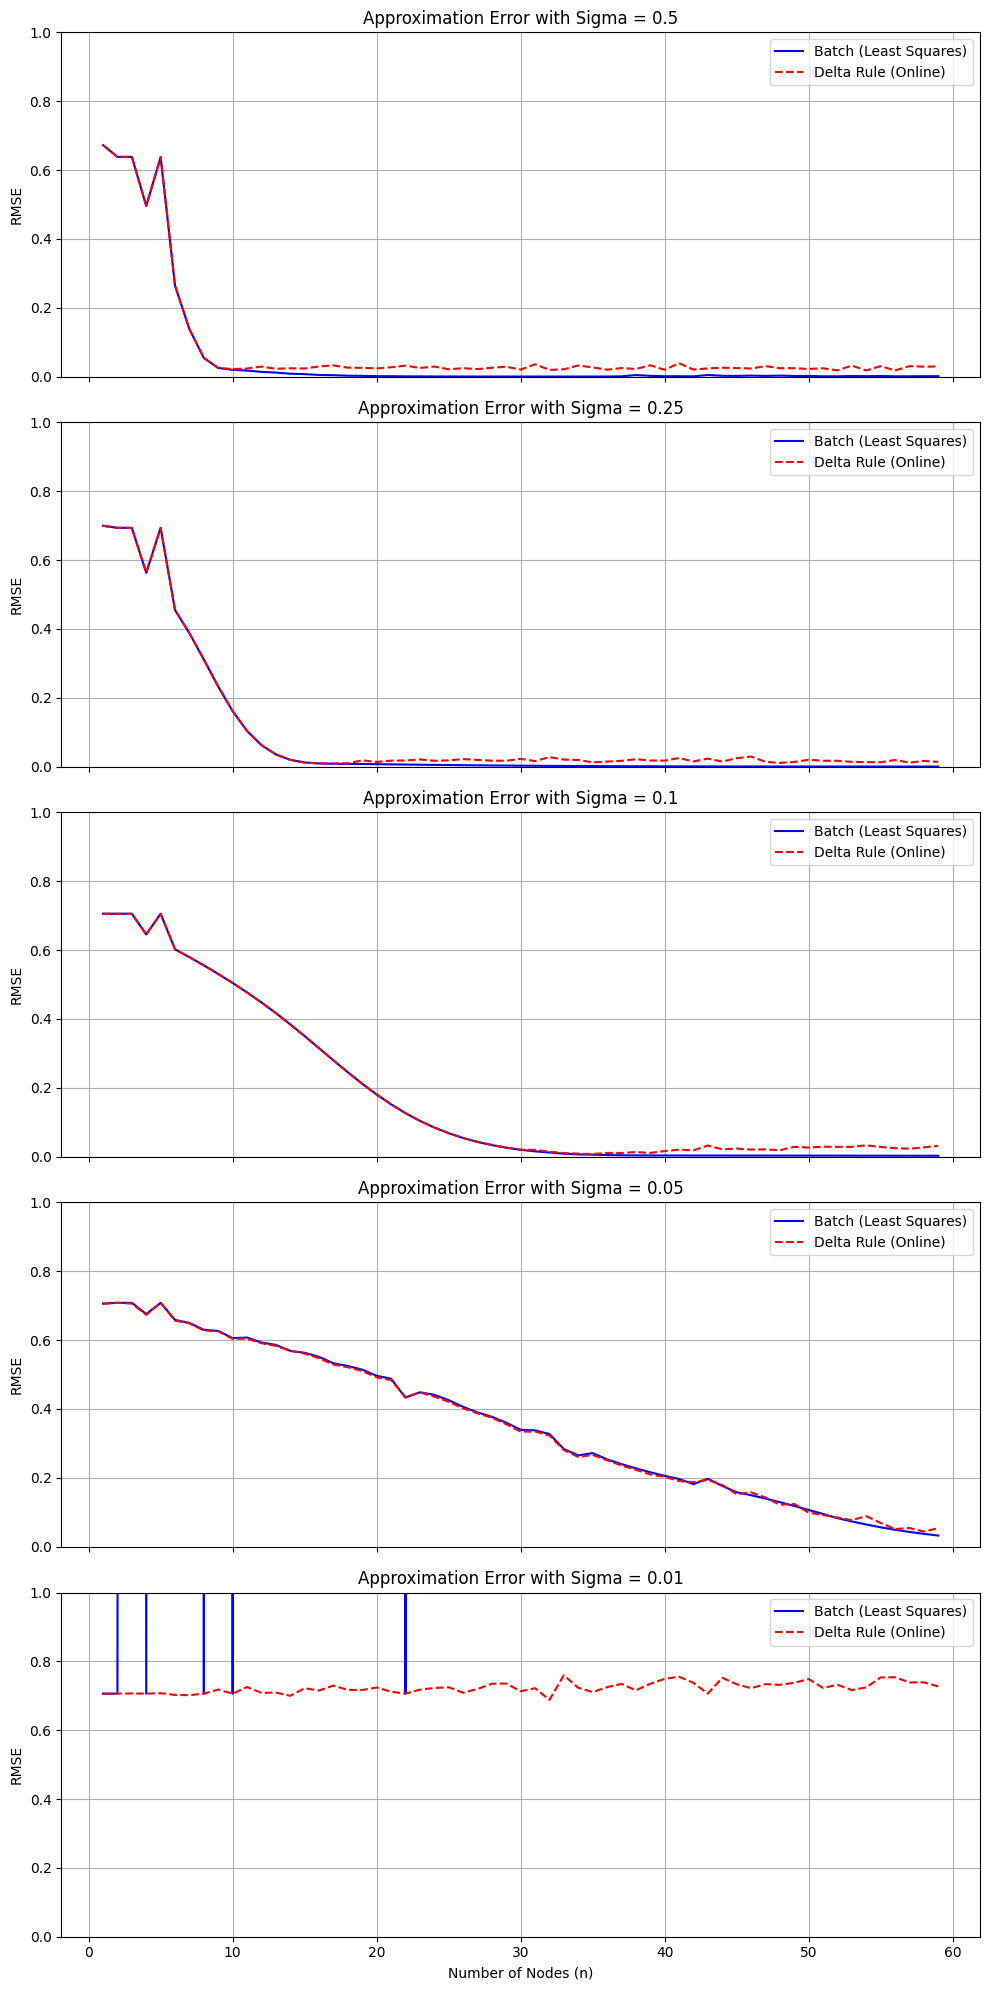

In [ ]:
sigmas = [0.5, 0.25, 0.1, 0.05, 0.01]
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10, 20), sharex=True)

for idx, s in enumerate(sigmas):
    errors_rbf = []
    errors_delta = []

    for n in n_range:
        nodes_mu = np.linspace(0, 2*np.pi, n)

        # Batch Mode (RBF)
        w_rbf = RBF_train(x_train, y_sin_train, nodes_mu, s)
        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, s)
        errors_rbf.append(rmse_error(y_sin_test, y_pred_rbf))

        # Delta Rule (Online)
        w_delta = delta_rule(x_train, y_sin_train, nodes_mu, s)
        y_pred_delta = predict(x_test, w_delta, nodes_mu, s)
        errors_delta.append(rmse_error(y_sin_test, y_pred_delta))


    print('Final Error with sigma = ', s)
    print('RBF: ', errors_rbf[-1])
    print('Delta: ', errors_delta[-1])
    axes[idx].plot(n_range, errors_rbf, label='Batch (Least Squares)', color='blue')
    axes[idx].plot(n_range, errors_delta, label='Delta Rule (Online)', color='red', linestyle='--')
    axes[idx].set_title(f"Approximation Error with Sigma = {s}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.0)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

Final Error with sigma =  0.5
RBF:  0.7438113172375656
Delta:  0.48047375206090975
Final Error with sigma =  0.25
RBF:  1.694893404668296
Delta:  0.2543932608623222
Final Error with sigma =  0.1
RBF:  0.23202830655085377
Delta:  0.22011569075567608
Final Error with sigma =  0.05
RBF:  0.2531996407866375
Delta:  0.24251482178782163
Final Error with sigma =  0.01
RBF:  75380.92433592993
Delta:  0.9851165576470066


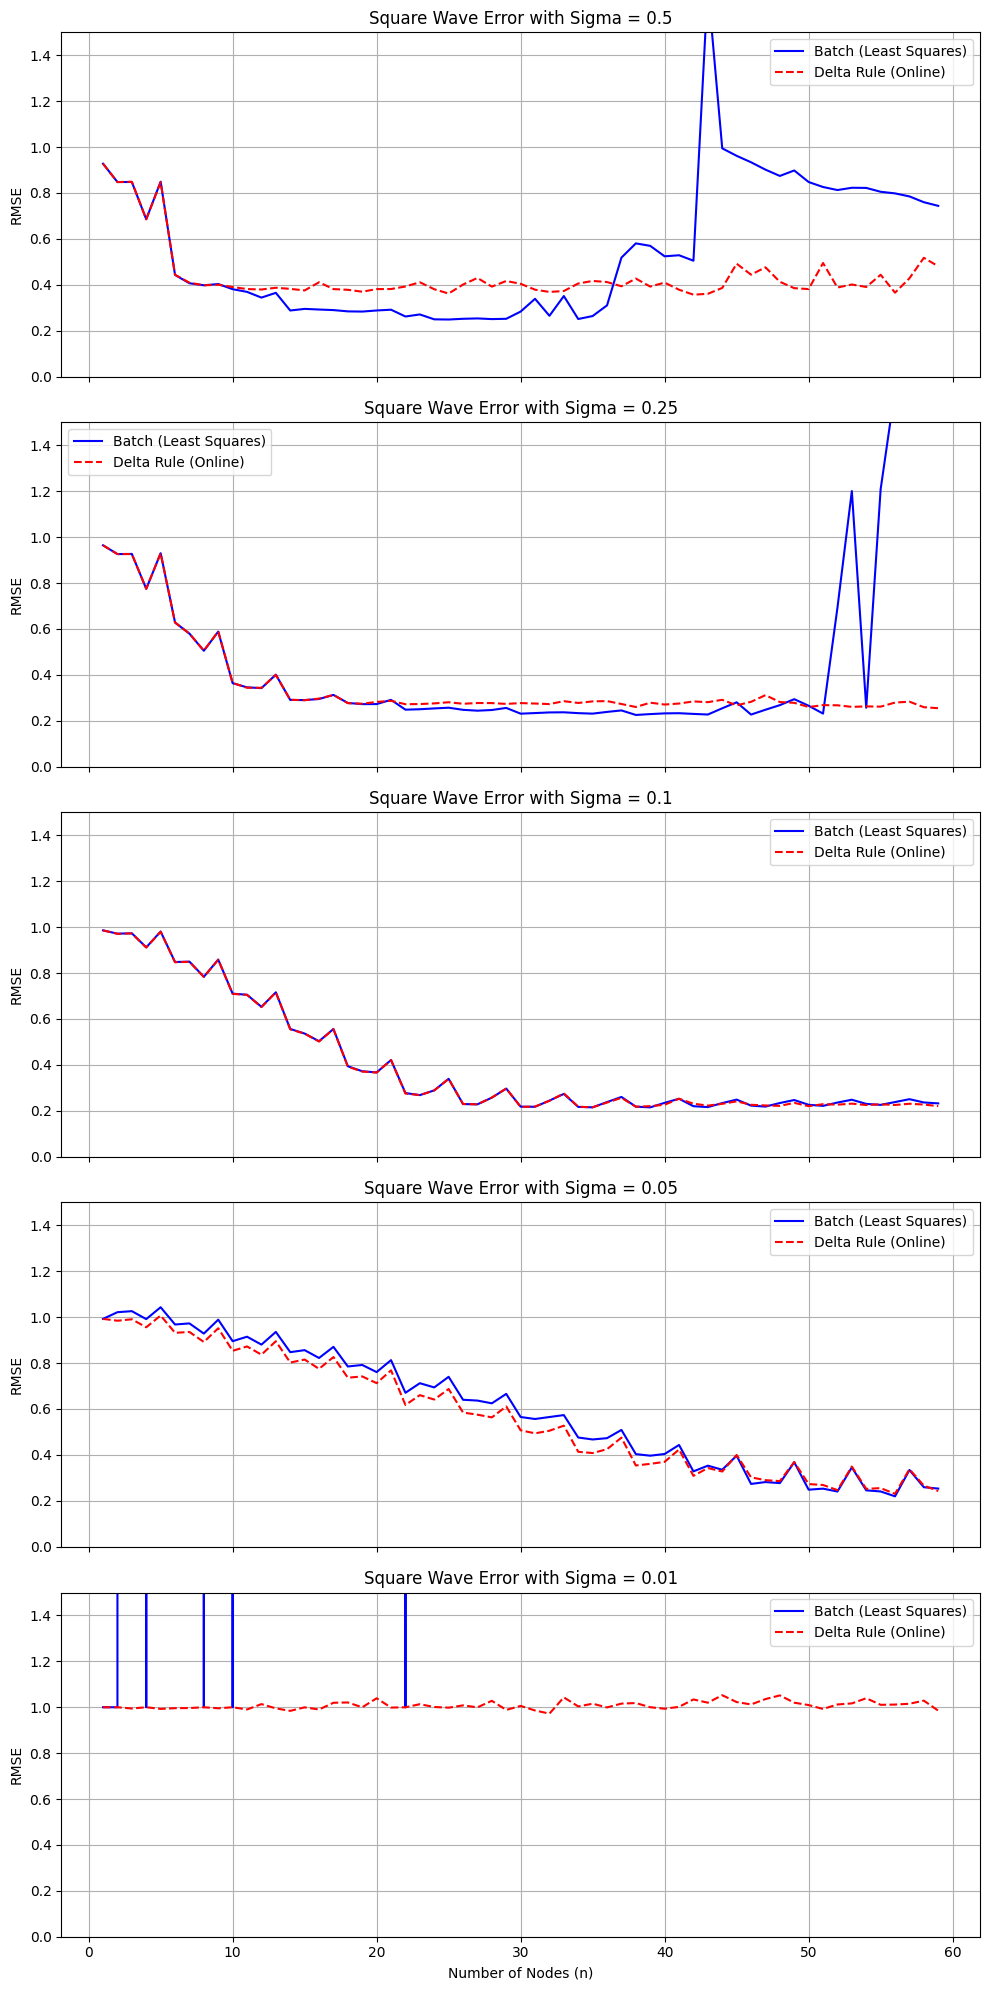

In [ ]:
sigmas = [0.5, 0.25, 0.1, 0.05, 0.01]
max_nodes = 60
n_range = range(1, max_nodes)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10, 20), sharex=True)

for idx, s in enumerate(sigmas):
    errors_rbf = []
    errors_delta = []

    for n in n_range:
        nodes_mu = np.linspace(0, 2*np.pi, n)

        w_rbf = RBF_train(x_train, y_square_train, nodes_mu, s)
        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, s)
        errors_rbf.append(rmse_error(y_square_test, y_pred_rbf))

        w_delta = delta_rule(x_train, y_square_train, nodes_mu, s)
        y_pred_delta = predict(x_test, w_delta, nodes_mu, s)
        errors_delta.append(rmse_error(y_square_test, y_pred_delta))


    print('Final Error with sigma = ', s)
    print('RBF: ', errors_rbf[-1])
    print('Delta: ', errors_delta[-1])
    axes[idx].plot(n_range, errors_rbf, label='Batch (Least Squares)', color='blue')
    axes[idx].plot(n_range, errors_delta, label='Delta Rule (Online)', color='red', linestyle='--')
    axes[idx].set_title(f"Square Wave Error with Sigma = {s}")
    axes[idx].set_ylabel("RMSE")
    axes[idx].set_ylim(0, 1.5)
    axes[idx].legend()
    axes[idx].grid(True)

plt.xlabel("Number of Nodes (n)")
plt.tight_layout()
plt.show()

MLP

In [ ]:
# --- MLP Core Logic (Source: Lab 1) ---

def transfer_function(x):
    """Bipolar sigmoid transfer function."""
    return 2 / (1 + np.exp(-x)) - 1

def der_transfer_function(x):
    """Derivative of the bipolar sigmoid."""
    phi = transfer_function(x)
    return (1 + phi) * (1 - phi) / 2

def forward_pass(w, v, X):
    """Forward propagation with bias."""
    ones = np.ones(X.shape[1]).reshape((1, X.shape[1]))
    X_in = np.vstack((X, ones))
    h_in = np.dot(w, X_in)
    h_out = transfer_function(h_in)
    H = np.vstack((h_out, ones))
    o_in = np.dot(v, H)
    o_out = transfer_function(o_in)
    return h_in, h_out, o_in, o_out, X_in, H

def backward_pass(h_in, h_out, o_in, o_out, t, v):
    """Compute error signals (deltas) for backprop."""
    delta_o = np.multiply((o_out - t), der_transfer_function(o_in))
    delta_h = np.multiply((np.dot(v[:, :-1].T, delta_o)), der_transfer_function(h_in))
    return delta_o, delta_h

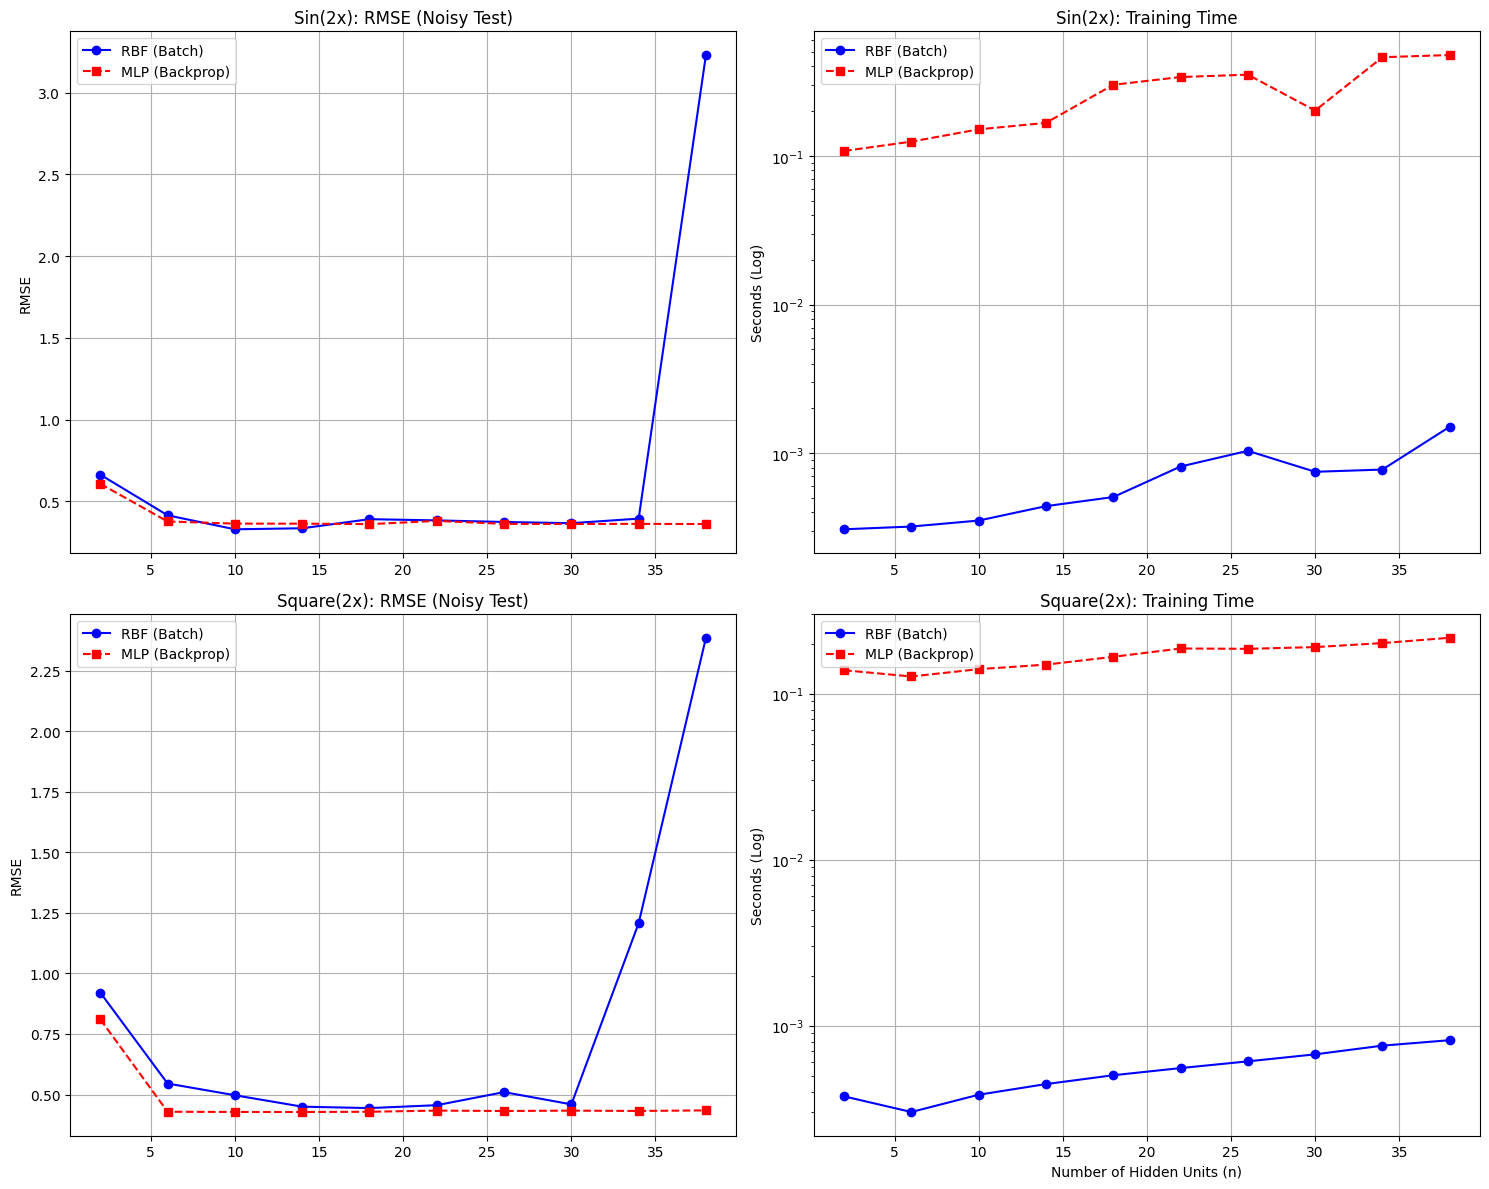

In [ ]:

# --- Configuration ---
learning_rate = 0.05
alpha = 0.9
number_epochs = 1500
sigma_rbf = 0.5
n_units_range = range(2, 41, 4)

# Define tasks for comparison
tasks = [
    ("Sin(2x)", y_sin_train_noisy, y_sin_test_noisy),
    ("Square(2x)", y_square_train_noisy, y_square_test_noisy)
]

# Plot setup: 2 rows (one for each function), 2 columns (RMSE and Time)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for row, (name, train_noisy, test_noisy) in enumerate(tasks):
    r_rmse, m_rmse = [], []
    r_time, m_time = [], []

    # MLP Data Prep
    X_train_mlp = x_train.reshape(1, -1)
    T_train_mlp = train_noisy.reshape(1, -1)
    X_test_mlp = x_test.reshape(1, -1)
    T_test_mlp = test_noisy.reshape(1, -1)

    for n in n_units_range:
        # 1. RBF Training (Batch Mode)
        start_rbf = time.time()
        nodes_mu = np.linspace(0, 2*np.pi, n)
        w_rbf = RBF_train(x_train, train_noisy, nodes_mu, sigma_rbf)
        r_time.append(time.time() - start_rbf)

        y_pred_rbf = predict(x_test, w_rbf, nodes_mu, sigma_rbf)
        r_rmse.append(rmse_error(y_pred_rbf, test_noisy))

        # 2. MLP Training (Batch Mode)
        w = np.random.normal(0, 0.1, (n, 2))
        v = np.random.normal(0, 0.1, (1, n + 1))
        dw, dv = 0, 0

        start_mlp = time.time()
        for _ in range(number_epochs):
            h_in, h_out, o_in, o_out, X_bias, H_bias = forward_pass(w, v, X_train_mlp)
            delta_o, delta_h = backward_pass(h_in, h_out, o_in, o_out, T_train_mlp, v)
            dw = dw * alpha - (1 - alpha) * np.dot(delta_h, X_bias.T)
            dv = dv * alpha - (1 - alpha) * np.dot(delta_o, H_bias.T)
            w += learning_rate * dw
            v += learning_rate * dv
        m_time.append(time.time() - start_mlp)

        _, _, _, y_pred_mlp, _, _ = forward_pass(w, v, X_test_mlp)
        m_rmse.append(rmse_error(y_pred_mlp.flatten(), test_noisy))

    # --- Plotting Metrics ---
    # RMSE Comparison
    axes[row, 0].plot(n_units_range, r_rmse, 'o-', label='RBF (Batch)', color='blue')
    axes[row, 0].plot(n_units_range, m_rmse, 's--', label='MLP (Backprop)', color='red')
    axes[row, 0].set_title(f"{name}: RMSE (Noisy Test)")
    axes[row, 0].set_ylabel("RMSE")
    axes[row, 0].legend()
    axes[row, 0].grid(True)

    # Time Comparison
    axes[row, 1].plot(n_units_range, r_time, 'o-', label='RBF (Batch)', color='blue')
    axes[row, 1].plot(n_units_range, m_time, 's--', label='MLP (Backprop)', color='red')
    axes[row, 1].set_yscale('log') # Use log scale because MLP is much slower
    axes[row, 1].set_title(f"{name}: Training Time")
    axes[row, 1].set_ylabel("Seconds (Log)")
    axes[row, 1].legend()
    axes[row, 1].grid(True)

plt.xlabel("Number of Hidden Units (n)")
plt.tight_layout()
plt.show()

## 3.3 Competitive learning (CL) to initialise RBF units

In [ ]:
def CL(x_train, nodes_mu, step_size=0.2, epochs = 5):
  w = np.random.uniform(0, 2 * np.pi, len(nodes_mu))
  indices = np.arange(len(x_train))
  for e in range(epochs):
    np.random.shuffle(indices)
    for i in indices:
      diff = (w-x_train[i])**2
      min_diff = np.argmin(diff)
      w[min_diff] = (1-step_size)*w[min_diff] + step_size*x_train[i]
  return w

In [ ]:
def plot_node_positions(linspace_mu, cl_mu, x_train):
    plt.figure(figsize=(12, 4))

    # Plot the underlying data distribution (density)
    plt.scatter(x_train, np.zeros_like(x_train) - 0.1, color='gray', alpha=0.1, label='Training Data Density')

    # Plot Linspace positions
    plt.scatter(linspace_mu, np.zeros_like(linspace_mu) + 0.1,
                color='blue', marker='|', s=500, label='Uniform Centers (linspace)')

    # Plot CL positions
    plt.scatter(cl_mu, np.zeros_like(cl_mu) + 0.2,
                color='red', marker='x', s=100, label='CL Centers (Learned)')

    plt.title("RBF Node Positions: Uniform vs. Competitive Learning")
    plt.xlabel("Input Space (0 to 2π)")
    plt.yticks([0.1, 0.2], ['Uniform', 'CL'])
    plt.ylim(-0.2, 0.5)
    plt.legend()
    plt.grid(True, axis='x', linestyle='--')
    plt.show()

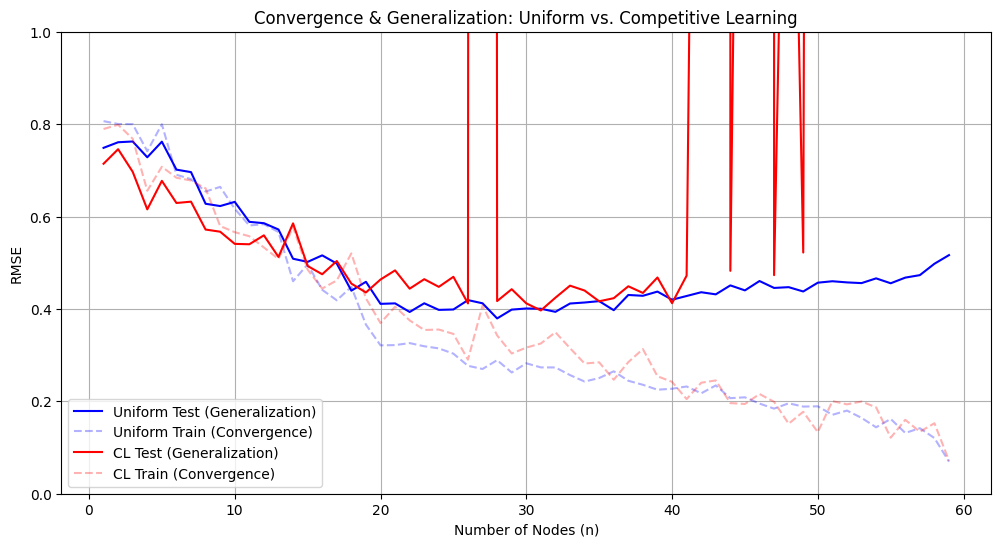

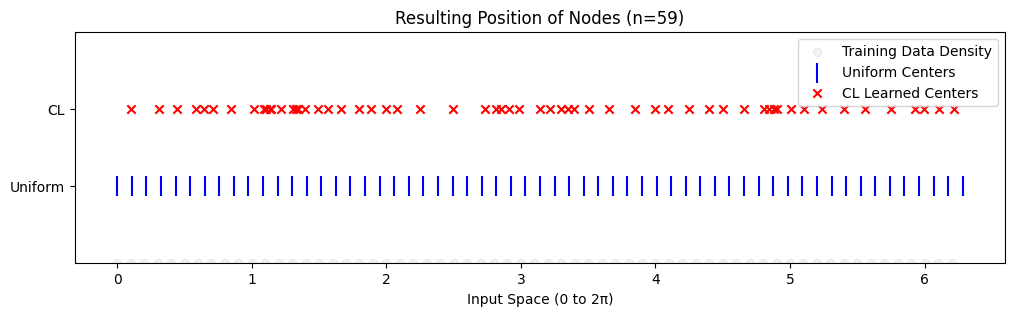

In [ ]:
# Parameters remain unchanged
sigma = 0.1
max_nodes = 60
n_range = range(1, max_nodes)

# Lists to track Training and Test errors (crucial for Generalization/Convergence analysis)
err_rbf_train, err_rbf_test = [], []
err_cl_train, err_cl_test = [], []

for n in n_range:
    nodes_mu = np.linspace(0, 2*np.pi, n)

    # 1. Standard Batch Mode (Uniform Centers)
    w_rbf = RBF_train(x_train, y_sin_train_noisy, nodes_mu, sigma)
    # Predictions for training and test sets
    y_pred_rbf_train = predict(x_train, w_rbf, nodes_mu, sigma)
    y_pred_rbf_test = predict(x_test, w_rbf, nodes_mu, sigma)

    # Store errors for convergence and generalization analysis
    err_rbf_train.append(rmse_error(y_pred_rbf_train, y_sin_train_noisy))
    err_rbf_test.append(rmse_error(y_pred_rbf_test, y_sin_test_noisy))

    # 2. Competitive Learning (CL) Mode
    # Generate learned centers using your CL function
    new_mu = CL(x_train, nodes_mu)
    w_cl = RBF_train(x_train, y_sin_train_noisy, new_mu, sigma)

    # Error calculation (IMPORTANT: predict now uses the correct 'new_mu')
    y_pred_cl_train = predict(x_train, w_cl, new_mu, sigma)
    y_pred_cl_test = predict(x_test, w_cl, new_mu, sigma)

    err_cl_train.append(rmse_error(y_pred_cl_train, y_sin_train_noisy))
    err_cl_test.append(rmse_error(y_pred_cl_test, y_sin_test_noisy))

# --- VISUALIZATION ---

# Plot 1: Convergence & Generalization Comparison
plt.figure(figsize=(12, 6))

# Uniform RBF curves
plt.plot(n_range, err_rbf_test, 'b-', label='Uniform Test (Generalization)')
plt.plot(n_range, err_rbf_train, 'b--', alpha=0.3, label='Uniform Train (Convergence)')

# Competitive Learning curves
plt.plot(n_range, err_cl_test, 'r-', label='CL Test (Generalization)')
plt.plot(n_range, err_cl_train, 'r--', alpha=0.3, label='CL Train (Convergence)')

plt.title("Convergence & Generalization: Uniform vs. Competitive Learning")
plt.xlabel("Number of Nodes (n)")
plt.ylabel("RMSE")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Final Node Positions (for the last iteration of n)
plt.figure(figsize=(12, 3))
# Scatter plot to show training data density
plt.scatter(x_train, np.zeros_like(x_train), color='gray', alpha=0.1, label='Training Data Density')
# Position of centers using Uniform vs. CL
plt.scatter(nodes_mu, np.ones_like(nodes_mu) * 0.5, color='blue', marker='|', s=200, label='Uniform Centers')
plt.scatter(new_mu, np.ones_like(new_mu) * 1.0, color='red', marker='x', label='CL Learned Centers')

plt.yticks([0.5, 1.0], ['Uniform', 'CL'])
plt.title(f"Resulting Position of Nodes (n={n})")
plt.xlabel("Input Space (0 to 2π)")
plt.ylim(0, 1.5)
plt.legend()
plt.show()

this one is only for noisy data

Against dead units by initializing the weights as data points


In [ ]:
def CL_dead(x_train, nodes_mu, step_size=0.2, epochs = 5):
  indices = np.arange(len(x_train))
  np.random.shuffle(indices)
  w = x_train[indices[:len(nodes_mu)]]
  for e in range(epochs):
    np.random.shuffle(indices)
    for i in indices:
      diff = (w-x_train[i])**2
      min_diff = np.argmin(diff)
      w[min_diff] = (1-step_size)*w[min_diff] + step_size*x_train[i]
  return w

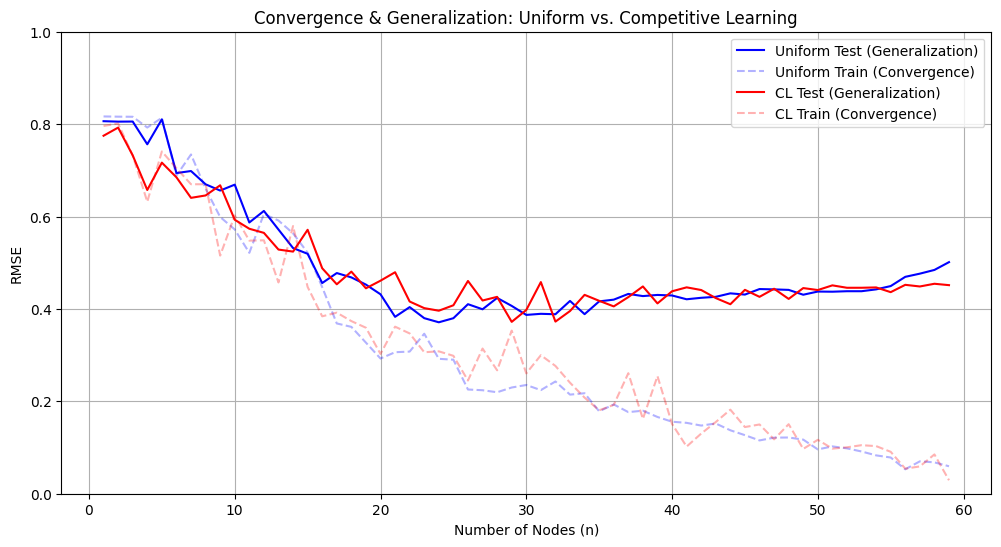

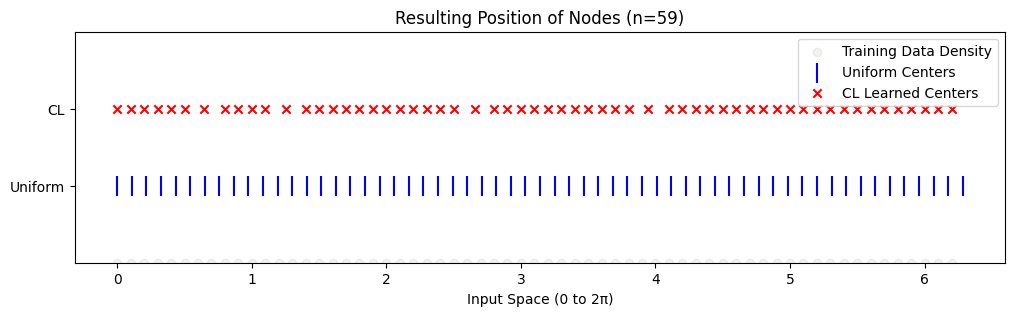

In [ ]:
# Parameters remain unchanged
sigma = 0.1
max_nodes = 60
n_range = range(1, max_nodes)

# Lists to track Training and Test errors (crucial for Generalization/Convergence analysis)
err_rbf_train, err_rbf_test = [], []
err_cl_train, err_cl_test = [], []

for n in n_range:
    nodes_mu = np.linspace(0, 2*np.pi, n)

    # 1. Standard Batch Mode (Uniform Centers)
    w_rbf = RBF_train(x_train, y_sin_train_noisy, nodes_mu, sigma)
    # Predictions for training and test sets
    y_pred_rbf_train = predict(x_train, w_rbf, nodes_mu, sigma)
    y_pred_rbf_test = predict(x_test, w_rbf, nodes_mu, sigma)

    # Store errors for convergence and generalization analysis
    err_rbf_train.append(rmse_error(y_pred_rbf_train, y_sin_train_noisy))
    err_rbf_test.append(rmse_error(y_pred_rbf_test, y_sin_test_noisy))

    # 2. Competitive Learning (CL) Mode
    # Generate learned centers using your CL function
    new_mu = CL_dead(x_train, nodes_mu)
    w_cl = RBF_train(x_train, y_sin_train_noisy, new_mu, sigma)

    # Error calculation (IMPORTANT: predict now uses the correct 'new_mu')
    y_pred_cl_train = predict(x_train, w_cl, new_mu, sigma)
    y_pred_cl_test = predict(x_test, w_cl, new_mu, sigma)

    err_cl_train.append(rmse_error(y_pred_cl_train, y_sin_train_noisy))
    err_cl_test.append(rmse_error(y_pred_cl_test, y_sin_test_noisy))

# --- VISUALIZATION ---

# Plot 1: Convergence & Generalization Comparison
plt.figure(figsize=(12, 6))

# Uniform RBF curves
plt.plot(n_range, err_rbf_test, 'b-', label='Uniform Test (Generalization)')
plt.plot(n_range, err_rbf_train, 'b--', alpha=0.3, label='Uniform Train (Convergence)')

# Competitive Learning curves
plt.plot(n_range, err_cl_test, 'r-', label='CL Test (Generalization)')
plt.plot(n_range, err_cl_train, 'r--', alpha=0.3, label='CL Train (Convergence)')

plt.title("Convergence & Generalization: Uniform vs. Competitive Learning")
plt.xlabel("Number of Nodes (n)")
plt.ylabel("RMSE")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Final Node Positions (for the last iteration of n)
plt.figure(figsize=(12, 3))
# Scatter plot to show training data density
plt.scatter(x_train, np.zeros_like(x_train), color='gray', alpha=0.1, label='Training Data Density')
# Position of centers using Uniform vs. CL
plt.scatter(nodes_mu, np.ones_like(nodes_mu) * 0.5, color='blue', marker='|', s=200, label='Uniform Centers')
plt.scatter(new_mu, np.ones_like(new_mu) * 1.0, color='red', marker='x', label='CL Learned Centers')

plt.yticks([0.5, 1.0], ['Uniform', 'CL'])
plt.title(f"Resulting Position of Nodes (n={n})")
plt.xlabel("Input Space (0 to 2π)")
plt.ylim(0, 1.5)
plt.legend()
plt.show()

2D RBF

In [ ]:
def gaussian_rbf_2D(x ,mus, sigma):
    return np.exp(-(((x[:,0] - mus[0])**2)+((x[:,1]-mus[1]))**2) / (2 * sigma**2))


def RBF_train_2D(x_train,y_train, nodes_mu, variance=0.05):
  n_nodes=len(nodes_mu)
  phi = np.zeros((len(x_train),n_nodes))

  for i in range(n_nodes):
    phi[:,i]=gaussian_rbf_2D(x_train,nodes_mu[i,:],variance)

  w = np.linalg.pinv(phi) @ y_train
  return w


def predict_2D(x_test,w, nodes_mu, variance=0.05):
  n_nodes=len(nodes_mu)
  phi_test = np.zeros((len(x_test),n_nodes))

  for i in range(n_nodes):
    phi_test[:,i]=gaussian_rbf_2D(x_test,nodes_mu[i,:],variance)

  return phi_test @ w

In [ ]:
def init_mu_from_data(x_train, n_nodes):
    indices = np.random.choice(len(x_train), n_nodes, replace=False)
    mu = x_train[indices].copy()
    return mu

In [ ]:
def CL_dead_2D(x_train, w, step_size=0.2, epochs = 5):
  indices = np.arange(len(x_train))
  for e in range(epochs):
    np.random.shuffle(indices)
    for i in indices:
      diff = (w-x_train[i,:])**2
      distance = np.sum(diff, axis=1)
      min_dis = np.argmin(distance)
      w[min_dis,:] = (1-step_size)*w[min_dis,:] + step_size*x_train[i,:]
  return w

In [ ]:
train_data = np.loadtxt('ballist.dat')
x_train = train_data[:,:2]
y_train = train_data[:,-2:]
test_data = np.loadtxt('balltest.dat')
x_test = test_data[:,:2]
y_test = test_data[:,-2:]

In [ ]:
max_nodes=10
for n in range(1,max_nodes):
  nodes_mu = init_mu_from_data(x_train,n)
  w = RBF_train_2D(x_train,y_train,nodes_mu)
  new_w=CL_dead_2D(x_train,w)
  y_pred=predict(x_test,new_w,nodes_mu)
  error = rmse_error(y_pred,y_test)
  print(error)

0.3006812679246191
0.28983541225809817
0.2602066383046866
0.2980226912888878
0.3035229373028966
0.2785773283334019
0.2744872176389188
0.2996072729044374
0.2795121259092854


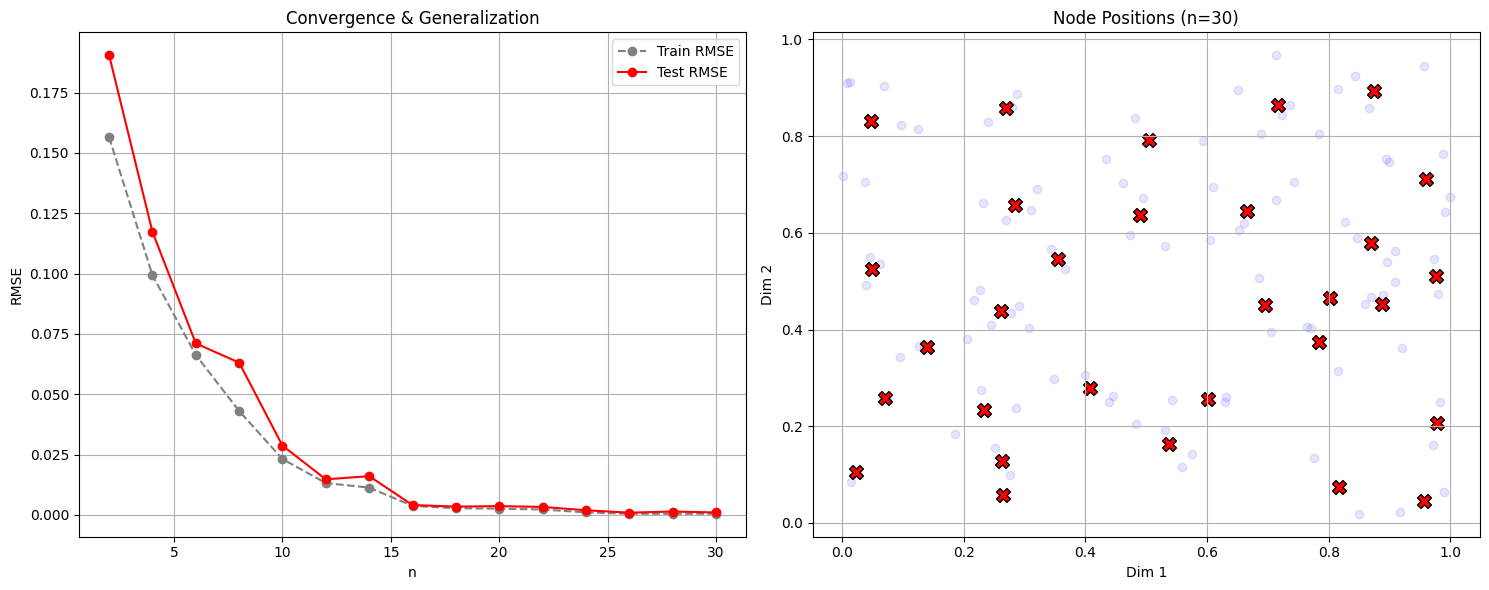

In [ ]:
max_nodes = 31
n_range = range(2, max_nodes, 2)
sigma = 0.5

train_errors = []
test_errors = []
final_mu_positions = None

for n in n_range:
    nodes_mu= init_mu_from_data(x_train,n)
    optimized_mu = CL_dead_2D(x_train, nodes_mu, step_size=0.1, epochs=20)
    w = RBF_train_2D(x_train, y_train, optimized_mu, sigma)

    y_pred_train = predict_2D(x_train, w, optimized_mu, sigma)
    y_pred_test = predict_2D(x_test, w, optimized_mu, sigma)

    train_errors.append(rmse_error(y_pred_train, y_train))
    test_errors.append(rmse_error(y_pred_test, y_test))

    final_mu_positions = optimized_mu

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(n_range, train_errors, 'o--', color='gray', label='Train RMSE')
ax1.plot(n_range, test_errors, 'o-', color='red', label='Test RMSE')
ax1.set_title("Convergence & Generalization")
ax1.set_xlabel("n")
ax1.set_ylabel("RMSE")
ax1.legend()
ax1.grid(True)

ax2.scatter(x_train[:, 0], x_train[:, 1], c='blue', alpha=0.1)
ax2.scatter(final_mu_positions[:, 0], final_mu_positions[:, 1], c='red', marker='X', s=100, edgecolors='black')
ax2.set_title(f"Node Positions (n={max_nodes-1})")
ax2.set_xlabel("Dim 1")
ax2.set_ylabel("Dim 2")
ax2.grid(True)

plt.tight_layout()
plt.show()

#PART 2


##4.1 Topological Ordering of Animal Species

In [ ]:
n_nodes = 100
n_x = 84
n_animals = 32
epochs = 20
step_size = 0.2
weights = np.random.uniform(0,1,(n_nodes,n_x))

data = np.loadtxt('animals.dat',delimiter=',')
data = data.reshape(n_animals,n_x)
# print(data)

#train SOM
for e in range(epochs):
    for a in range(n_animals):
      diff = np.sqrt(np.sum((weights-data[a,:])**2,axis=1))
      min_diff = np.argmin(diff)
      neighbor_size = 50- e*(49/epochs-1)

      start = int(max(0, min_diff - neighbor_size))
      stop = int(min(n_nodes, min_diff + neighbor_size + 1))
      neighborhood = np.arange(start, stop)
      for n in neighborhood:
        weights[n,:] = (1-step_size)*weights[n,:] + step_size*data[a,:]

#calculate results
pos = np.zeros(n_animals)
for a in range(n_animals):
  diff = np.sqrt(np.sum((weights-data[a,:])**2,axis=1))
  pos[a] = np.argmin(diff)

#load animal names
with open('animalnames.txt', 'r') as f:
    animal_names = [line.strip().replace('"', '').replace("'", "") for line in f]

results = sorted(zip(pos,animal_names))

for node, name in results:
    print(f"Node {node}: {name}")


Node 0.0: beetle
Node 0.0: butterfly
Node 0.0: dragonfly
Node 0.0: grasshopper
Node 0.0: housefly
Node 0.0: moskito
Node 4.0: spider
Node 28.0: duck
Node 28.0: ostrich
Node 28.0: pelican
Node 28.0: penguin
Node 31.0: frog
Node 31.0: seaturtle
Node 35.0: crocodile
Node 54.0: walrus
Node 58.0: bear
Node 58.0: dog
Node 58.0: lion
Node 59.0: cat
Node 61.0: ape
Node 61.0: hyena
Node 77.0: bat
Node 81.0: skunk
Node 82.0: rat
Node 83.0: rabbit
Node 86.0: kangaroo
Node 87.0: elephant
Node 98.0: horse
Node 99.0: antelop
Node 99.0: camel
Node 99.0: giraffe
Node 99.0: pig


## 4.2 Cyclic Tour

In [131]:
def calculate_neighborhood(min_diff,n_nodes,n_epochs,epoch):
  neighbor_size = 2 - epoch // (n_epochs//3)
  offsets = np.arange(-neighbor_size, neighbor_size + 1)
  neighborhood_indices = (min_diff + offsets) % n_nodes
  return neighborhood_indices.astype(int)

[[0.4    0.4439]
 [0.2439 0.1463]
 [0.1707 0.2293]
 [0.2293 0.761 ]
 [0.5171 0.9414]
 [0.8732 0.6536]
 [0.6878 0.5219]
 [0.8488 0.3609]
 [0.6683 0.2536]
 [0.6195 0.2634]]


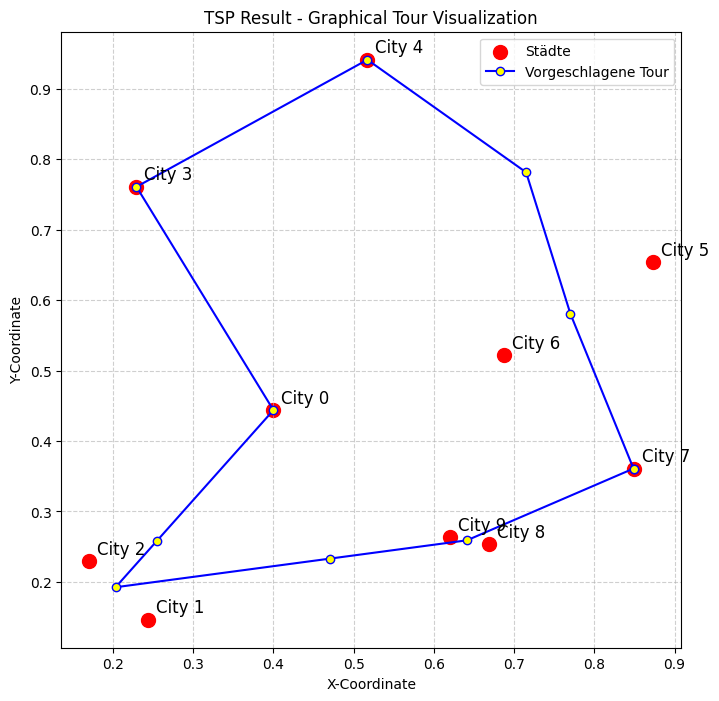

In [135]:
n_nodes = 10
n_dim = 2
n_cities = 10
epochs = 200
step_size = 0.2
weights = np.random.uniform(0,1,(n_nodes,n_dim))

with open('cities.dat', 'r') as f:
  lines = [line.replace(';', '').replace(',', ' ')
            for line in f if not line.strip().startswith('%')]

data = np.loadtxt(lines)
data = data.reshape(n_cities,n_dim)
print(data)

#train SOM
for e in range(epochs):
    for c in range(n_cities):
      diff = np.sqrt(np.sum((weights-data[c,:])**2,axis=1))
      min_diff = np.argmin(diff)

      neighborhood = calculate_neighborhood(min_diff,n_nodes,epochs,e)
      for n in neighborhood:
        weights[n,:] = (1-step_size)*weights[n,:] + step_size*data[c,:]


# Append the first node to the end to close the tour ring
tour = np.vstack([weights, weights[0]])

plt.figure(figsize=(8, 8))

# Plot the actual cities (Red dots)
plt.scatter(data[:, 0], data[:, 1], c='red', s=100, label='Städte')

# Plot the suggested tour (Blue line with yellow nodes)
plt.plot(tour[:, 0], tour[:, 1], 'b-o', mfc='yellow', label='Vorgeschlagene Tour')

for i, (x, y) in enumerate(data):
    plt.text(x + 0.01, y + 0.01, f'City {i}', fontsize=12)

plt.title("TSP Result - Graphical Tour Visualization")
plt.xlabel("X-Coordinate")
plt.ylabel("Y-Coordinate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



Result is not optimal because we would wish to have every node on one of the cities. Maybe we would need even more epochs or a higher step size

##4.3 Data Clustering: Votes of MPs


In [150]:
def calculate_neighborhood_2D(min_idx,grid_shape,n_epochs ,epoch):
    neighbor_size = 7 - epoch // (n_epochs//8)
    row_start = max(0, min_idx[0] - neighbor_size)
    row_end = min(grid_shape[0], min_idx[0] + neighbor_size + 1)

    col_start = max(0, min_idx[1] - neighbor_size)
    col_end = min(grid_shape[1], min_idx[1] + neighbor_size + 1)

    rows = np.arange(row_start, row_end)
    cols = np.arange(col_start, col_end)

    rows_grid, cols_grid = np.meshgrid(rows, cols)

    # Return as a list of (row, col) pairs
    return np.column_stack([rows_grid.ravel(), cols_grid.ravel()])

In [161]:
n_nodes = np.zeros((10,10))
n_dim = 31
n_MPS = 349
epochs = 20
step_size = 0.2
weights = np.random.uniform(0,1,(n_nodes.shape[0],n_nodes.shape[1],n_dim))
# print(weights.shape)


data = np.loadtxt('votes.dat',delimiter=',')
data = data.reshape(n_MPS,n_dim)
# print(data)

#train SOM
for e in range(epochs):
    for mp in range(n_MPS):
      diff = np.sqrt(np.sum((weights-data[mp,:])**2,axis=-1))
      min_diff = np.argmin(diff)
      min_idx = np.unravel_index(min_diff, diff.shape)
      neighborhood = calculate_neighborhood_2D(min_idx,n_nodes.shape,epochs,e)
      for r ,c  in neighborhood:
        weights[r,c,:] = (1-step_size)*weights[r,c,:] + step_size*data[mp,:]

#calculate winner
node_occupancy = [[[] for _ in range(10)] for _ in range(10)]
for mp in range(n_MPS):
    diff = np.sqrt(np.sum((weights-data[mp,:])**2,axis=-1))
    min_diff = np.argmin(diff)
    r, c = np.unravel_index(min_diff, diff.shape)
    node_occupancy[r][c].append(mp)

In [179]:
def plot_som_attribute(node_occupancy,attribute_data, title,cmap_table='tab10'):
    vis_matrix = np.zeros((10, 10))

    for r in range(10):
        for c in range(10):
            mps_in_node = node_occupancy[r][c]
            if mps_in_node:
                attrs = [attribute_data[i] for i in mps_in_node]
                majority_attr = max(set(attrs), key=attrs.count)
                vis_matrix[r][c] = majority_attr
            else:
                vis_matrix[r][c] = -1

    plt.figure(figsize=(8, 6))
    plt.imshow(vis_matrix, cmap=cmap_table)
    plt.colorbar(label='Attribute Value')
    plt.title(title)
    plt.show()

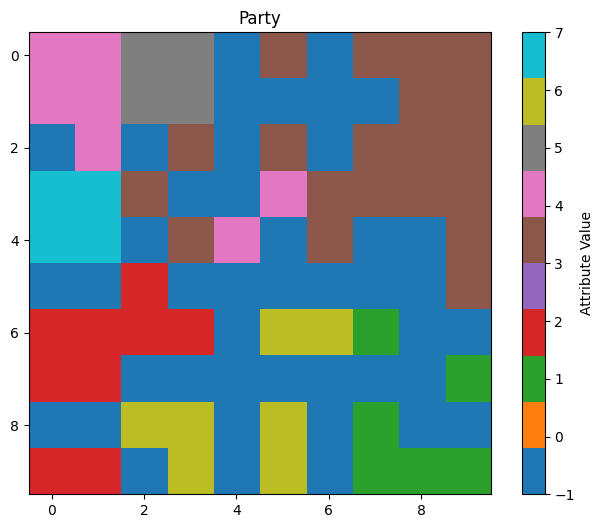

Code 0: Independent (Neutral)
Code 1: Moderaterna (Liberal-conservative, Center-right)
Code 2: Folkpartiet/Liberalerna (Liberal, Center-right)
Code 3: Socialdemokraterna (Social democratic, Center-left)
Code 4: Vänsterpartiet (Socialist, Left-wing)
Code 5: Miljöpartiet (Green, Center-left)
Code 6: Kristdemokraterna (Christian democratic, Center-right)
Code 7: Centerpartiet (Liberal/Agrarian, Center)


In [182]:
with open('mpparty.dat', 'r') as f:
  lines = [line.replace(';', '').replace(',', ' ')
            for line in f if not line.strip().startswith('%')]
party_data = np.loadtxt(lines)

plot_som_attribute(node_occupancy, party_data, 'Party')
party_info = {
    0: "Independent (Neutral)",
    1: "Moderaterna (Liberal-conservative, Center-right)",
    2: "Folkpartiet/Liberalerna (Liberal, Center-right)",
    3: "Socialdemokraterna (Social democratic, Center-left)",
    4: "Vänsterpartiet (Socialist, Left-wing)",
    5: "Miljöpartiet (Green, Center-left)",
    6: "Kristdemokraterna (Christian democratic, Center-right)",
    7: "Centerpartiet (Liberal/Agrarian, Center)"
}

for code, description in party_info.items():
    print(f"Code {code}: {description}")

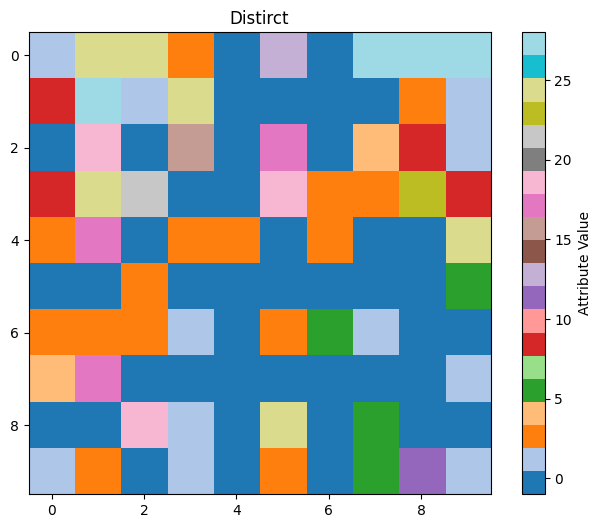

In [183]:

with open('mpdistrict.dat', 'r') as f:
  lines = [line.replace(';', '').replace(',', ' ')
            for line in f if not line.strip().startswith('%')]
party_data = np.loadtxt(lines)

plot_som_attribute(node_occupancy, party_data, 'Distirct','tab20')



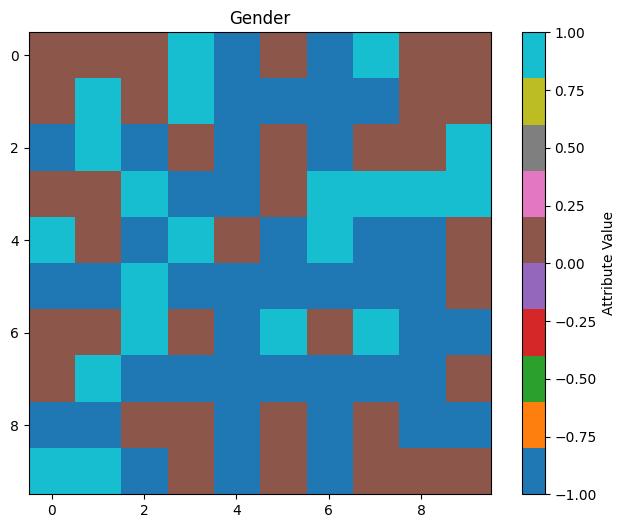

In [175]:
with open('mpsex.dat', 'r') as f:
  lines = [line.replace(';', '').replace(',', ' ')
            for line in f if not line.strip().startswith('%')]
party_data = np.loadtxt(lines)

plot_som_attribute(node_occupancy, party_data, 'Gender')

